## 10.26反馈：
做的非常好。使用了sklearn库中的OneHotEncoder对词语进行了one-hot编码，举了两个例子。在构建词袋模型时的思路流程是完全正确的，根据分词结果手动构建词汇表并进行one-hot编码。构建词汇表的过程写的很清晰，体现了最基本的原理。但最后计算TF-IDF的代码好像缺失了，运行结果里有计算了TF-IDF矩阵之后的结果，但代码中没有体现。可以进行补充。还有第一段代码的作用可以详细说明一下。

现在你主要使用的是sklearn中的OneHotEncoder函数进行one-hot编码，接下来一周去了解一下sklearn库中的TfidfVectorizer函数，调用这个函数可直接进行编码并生成TF-IDF加权后的词袋矩阵，不需要按照最底层的顺序一步步来做。同时，构建词表也有更简单的命令，将每个句子分词后的结果存放在一个字符串中，词与词之间用空格隔开，这样就可以直接使用.get_feature_names_out()指令创建对应的词汇表。最重要的是多找几个句子，生成每个句子的词袋模型矩阵后进行相似度计算（可以多用几种计算方法），并且尝试将结果可视化，例如生成热力图。
    
除了代码之外，学习一下几种相似度计算的方法（余弦相似度、欧氏距离等），理解计算公式，下周可以给大家讲讲。

One-Hot

In [2]:
from sklearn import preprocessing
import numpy as np
enc=preprocessing.OneHotEncoder()
data = np.array([[0, 0, 3],
                 [1, 1, 0], 
                 [0, 2, 1],
                 [1, 0, 2]])
#先用fit学习数据的特征
enc.fit(data)
#再用transform转换数据
array=enc.transform(data).toarray()
print(array)

[[1. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 1. 0.]]


In [ ]:
## 这

In [3]:
from sklearn.preprocessing import OneHotEncoder
# 创建示例数据（纯Python列表）
data = [['红色'], ['蓝色'], ['绿色'], ['红色'], ['蓝色']]
# 创建并训练编码器
#上一段代码中是import全部的sklearn库，这里只import OneHotEncoder
encoder = OneHotEncoder(sparse_output=True)
#上面括号里的是用来控制输出格式的false返回密集矩阵，易于查看操作，而true返回稀疏矩阵，节省内存（默认是true）
#这里讲fit与transform结合在了一起
encoded_data = encoder.fit_transform(data)
# 查看结果
print("原始数据:", data)
print("编码结果:")
print(encoded_data)
print("特征名称:", encoder.get_feature_names_out(['颜色']))
# get_feature_names_out(['颜色']) 中的 ['颜色'] 是输入特征的名称
# 它告诉编码器："这些编码后的特征来自于名为'颜色'的原始特征"

原始数据: [['红色'], ['蓝色'], ['绿色'], ['红色'], ['蓝色']]
编码结果:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>
  Coords	Values
  (0, 0)	1.0
  (1, 2)	1.0
  (2, 1)	1.0
  (3, 0)	1.0
  (4, 2)	1.0
特征名称: ['颜色_红色' '颜色_绿色' '颜色_蓝色']


In [4]:
import numpy as np
# 创建学生数据
student_data = np.array([
    ['大一', 'A'],
    ['大二', 'B'], 
    ['大三', 'A'],
    ['大一', 'C'],
    ['大二', 'B']
])
print("原始数据:")
print(student_data)
# 创建并训练编码器
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(student_data)
print("\nOne-Hot编码结果:")
print(encoded_data)
print("\n特征含义:")
print(encoder.get_feature_names_out(['年级', '成绩等级']))
# 测试新数据
new_student = np.array([['大一', 'B']])
new_encoded = encoder.transform(new_student)
print(f"\n新数据 ['大一', 'B'] 编码结果:")
print(new_encoded[0])

原始数据:
[['大一' 'A']
 ['大二' 'B']
 ['大三' 'A']
 ['大一' 'C']
 ['大二' 'B']]

One-Hot编码结果:
[[1. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 1. 0.]]

特征含义:
['年级_大一' '年级_大三' '年级_大二' '成绩等级_A' '成绩等级_B' '成绩等级_C']

新数据 ['大一', 'B'] 编码结果:
[1. 0. 0. 0. 1. 0.]


Bag of words

In [1]:
from collections import defaultdict  # 使用默认字典来统计词频
import jieba
# 创建词袋模型的函数
def simple_bag_of_words(documents):
    """
    简单的词袋模型实现
    输入：文档列表，例如 ["hello world", "hello python"]
    输出：词袋向量和词汇表
    """
    #上方是文档字符串，用于描述函数的输入输出
    # 步骤1：对中文文档进行分词
    print("=== 分词结果 ===")
    segmented_docs = []  # 存储分词后的文档
    for doc in documents:
        words = jieba.lcut(doc)  # 使用jieba进行中文分词
        segmented_docs.append(words)
        print(f"文档 '{doc}' 分词结果: {words}")
    print()  # 空行
    # 步骤2：构建词汇表
    vocabulary = {}  # 创建一个空字典来存储词汇表
    index = 0        # 词汇索引从0开始
    # 遍历所有分词后的文档
    for words in segmented_docs:    # 对每个文档的分词结果
        for word in words:          # 对每个单词
            if word not in vocabulary:  # 如果单词不在词汇表中
                vocabulary[word] = index  # 将单词添加到词汇表
                index += 1           # 索引加1
    print("词汇表:", vocabulary)  # 打印词汇表
    # 步骤3：创建词袋向量
    bag_of_words_vectors = [] # 创建空列表来存储所有文档的向量
    for i,words in enumerate(segmented_docs):  # 对每个文档
        # 初始化一个全0向量，长度等于词汇表大小
        vector = [0] * len(vocabulary)
        # 统计当前文档中每个单词的出现次数
        for word in words:  # 遍历文档中的每个单词
            if word in vocabulary:  # 如果单词在词汇表中
                # 找到单词在词汇表中的位置，并在对应位置计数加1
                vector[vocabulary[word]] += 1
        bag_of_words_vectors.append(vector)  # 将当前文档的向量添加到结果列表
        print(f"文档 '{doc}' 的词袋向量: {vector}")
    return bag_of_words_vectors, vocabulary,segmented_docs
##下面这一段为新增的。
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
def calculate_tfidf_from_segmented(segmented_docs, vocabulary, original_documents):
    """
    使用已经分好词的结果计算TF-IDF
    """
    print("\n=== 使用已分词结果计算TF-IDF ===")
    # 将分词结果转换为空格分隔的字符串（sklearn需要的格式）
    segmented_texts = [' '.join(words) for words in segmented_docs]
    print("分词后的文本:")
    for i, text in enumerate(segmented_texts):
        print(f"文档{i+1}: {text}")
    # 创建TF-IDF向量器，使用已有的词汇表
    tfidf_vectorizer = TfidfVectorizer(vocabulary=vocabulary)
    # 计算TF-IDF矩阵
    tfidf_matrix = tfidf_vectorizer.fit_transform(segmented_texts)
    # 获取特征词汇（按词汇表的顺序）
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("\nTF-IDF矩阵形状:", tfidf_matrix.shape)
    print("特征词汇:", feature_names)
    # 转换为DataFrame便于查看
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=[f"文档{i+1}" for i in range(len(original_documents))]
    )
    print("\nTF-IDF矩阵:")
    print(tfidf_df.round(3))
    
    return tfidf_matrix, tfidf_vectorizer
# 使用示例
if __name__ == "__main__":
    # 示例文档集
    documents = [
        "我喜欢编程",
        "编程很有趣", 
        "我喜欢学习"
    ]
    print("输入文档:", documents)
    print("\n处理过程:")
    #调用词袋模型函数
    vectors, vocab, segmented_docs = simple_bag_of_words(documents)
    print("\n=== 最终结果 ===")
    print("词汇表:", vocab)
    print("所有文档的词袋向量:")
    for i, vector in enumerate(vectors):
        print(f"文档{i+1}: {vector}")
      # 使用已经分好词的结果计算TF-IDF
    tfidf_matrix, vectorizer = calculate_tfidf_from_segmented(segmented_docs, vocab, documents)
    ## ##为第二次增加的，我也不知道为什么上次的那个代码可以跑出结果，然后感觉少了一段。
    ##上面这个函数调用是利用分好词的结果来计算TF-IDF（segmented_docs是分好词的文档列表，vocab是已经构建好的词汇表，documents是原始文档）

D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\GOIEUD~1\AppData\Local\Temp\jieba.cache


输入文档: ['我喜欢编程', '编程很有趣', '我喜欢学习']

处理过程:
=== 分词结果 ===


Loading model cost 1.697 seconds.
Prefix dict has been built successfully.


文档 '我喜欢编程' 分词结果: ['我', '喜欢', '编程']
文档 '编程很有趣' 分词结果: ['编程', '很', '有趣']
文档 '我喜欢学习' 分词结果: ['我', '喜欢', '学习']

词汇表: {'我': 0, '喜欢': 1, '编程': 2, '很': 3, '有趣': 4, '学习': 5}
文档 '我喜欢学习' 的词袋向量: [1, 1, 1, 0, 0, 0]
文档 '我喜欢学习' 的词袋向量: [0, 0, 1, 1, 1, 0]
文档 '我喜欢学习' 的词袋向量: [1, 1, 0, 0, 0, 1]

=== 最终结果 ===
词汇表: {'我': 0, '喜欢': 1, '编程': 2, '很': 3, '有趣': 4, '学习': 5}
所有文档的词袋向量:
文档1: [1, 1, 1, 0, 0, 0]
文档2: [0, 0, 1, 1, 1, 0]
文档3: [1, 1, 0, 0, 0, 1]

=== 使用已分词结果计算TF-IDF ===
分词后的文本:
文档1: 我 喜欢 编程
文档2: 编程 很 有趣
文档3: 我 喜欢 学习

TF-IDF矩阵形状: (3, 6)
特征词汇: ['我' '喜欢' '编程' '很' '有趣' '学习']

TF-IDF矩阵:
       我     喜欢     编程    很     有趣     学习
文档1  0.0  0.707  0.707  0.0  0.000  0.000
文档2  0.0  0.000  0.605  0.0  0.796  0.000
文档3  0.0  0.605  0.000  0.0  0.000  0.796


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
# 完全使用sklearn自带的函数
def sklearn_tfidf_only(documents):
    """
    完全使用sklearn计算TF-IDF，包含自动分词
    """
    print("=== 完全使用sklearn计算TF-IDF ===")
    print("原始文档:", documents)
    # sklearn自动完成所有步骤：分词 + 构建词汇表 + 计算TF-IDF
    #创建TF-IDF计算器，指定分词器为jieba的lcut函数
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None 
)
    #计算TF-IDF
    tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
    # 获取结果
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动分词的词汇表:", feature_names)
    print("TF-IDF矩阵形状:", tfidf_matrix.shape)
    # 显示结果
    #将TF-IDF矩阵转换为易读的DataFrame格式
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=[f"文档{i+1}" for i in range(len(documents))]
    )
    print("TF-IDF矩阵:")
    print(tfidf_df.round(3))
    return tfidf_matrix, tfidf_vectorizer
# 直接调用（不需要你的词袋模型函数）
if __name__ == "__main__":
    documents = [
        "我喜欢编程",
        "编程很有趣", 
        "我喜欢学习"
    ]
    tfidf_matrix, vectorizer = sklearn_tfidf_only(documents)

=== 完全使用sklearn计算TF-IDF ===
原始文档: ['我喜欢编程', '编程很有趣', '我喜欢学习']
自动分词的词汇表: ['我喜欢学习' '我喜欢编程' '编程很有趣']
TF-IDF矩阵形状: (3, 3)
TF-IDF矩阵:
     我喜欢学习  我喜欢编程  编程很有趣
文档1    0.0    1.0    0.0
文档2    0.0    0.0    1.0
文档3    1.0    0.0    0.0


In [18]:
import jieba
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
# 设置显示选项
pd.set_option('display.max_columns', None)
# 显示DataFrame的所有列，不限制列数
pd.set_option('display.width', 1000)
# 设置控制台显示的宽度为1000字符
def simple_tfidf_analysis(documents):
    """
    简单的TF-IDF分析：分词、构建词表、计算TF-IDF
    """
    # 显示原始文档
    print("=== 原始文档 ===")
    for i, doc in enumerate(documents, 1):
        print("文档" + str(i) + ": " + doc)
    # 步骤1: 分词并用空格连接
    print("=== 步骤1: 分词处理 ===")
    processed_docs = []
    for i, doc in enumerate(documents, 1):
        # 使用jieba分词
        words = jieba.lcut(doc)
        # 用空格连接分词结果
        processed_doc = ' '.join(words)
        processed_docs.append(processed_doc)
        print("文档" + str(i) + ":")
        print("  原始: " + doc)
        print("  分词: " + str(words))
        print("  连接: '" + processed_doc + "'\n")
    print("=" * 60)
    # 步骤2: 使用TfidfVectorizer计算TF-IDF
    print("=== 步骤2: 计算TF-IDF ===")
    # 创建TF-IDF向量器，按空格分词
    # TfidfVectorizer是scikit-learn中用于将文本转换为TF-IDF特征向量的类
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None 
)
    #tokenizer指定分词器函数
    #lambda x: x.split()一个匿名函数，接收文本x，用空格进行分词
    # 拟合和转换数据
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
    print("TF-IDF计算完成！")
    print("矩阵形状: " + str(tfidf_matrix.shape) + " (文档数 × 词汇表大小)")
    # 步骤3: 获取词汇表
    print("=== 步骤3: 获取词汇表 ===")
    # 使用.get_feature_names_out()一键获取词汇表
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动构建的词汇表 (共" + str(len(feature_names)) + "个词):")
    # 每行显示5个词
    for i in range(0, len(feature_names), 5):
        line_words = feature_names[i:i+5]
        line_display = ""
        for j, word in enumerate(line_words):
            line_display += str(i+j+1) + "." + word + " " * (10 - len(word))
        print("  " + line_display)
    # 步骤4: 显示TF-IDF矩阵
    print("=== 步骤4: TF-IDF矩阵 ===")
    # 创建DataFrame显示结果
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=["文档" + str(i) for i in range(1, len(documents)+1)]
    )
    print("TF-IDF矩阵 (值越大表示词越重要):")
    print(tfidf_df.round(3))
    return tfidf_df, tfidf_vectorizer, processed_docs
documents = [
    "机器学习是人工智能的核心技术",
    "深度学习需要大量的训练数据",
    "监督学习使用标注数据进行训练",
    "Python是数据科学的首选语言",
    "Java在企业级开发中广泛应用",
    "数据分析需要统计学知识",
    "数据可视化帮助理解数据分布",
    "人工智能正在改变各行各业"
]
# 执行TF-IDF分析
tfidf_df, vectorizer, processed_docs = simple_tfidf_analysis(documents)
# 显示统计信息
print("=== 统计信息 ===")
print("处理文档数量: " + str(len(documents)))
print("词汇表大小: " + str(len(vectorizer.get_feature_names_out())))
print("TF-IDF矩阵形状: " + str(tfidf_df.shape))

=== 原始文档 ===
文档1: 机器学习是人工智能的核心技术
文档2: 深度学习需要大量的训练数据
文档3: 监督学习使用标注数据进行训练
文档4: Python是数据科学的首选语言
文档5: Java在企业级开发中广泛应用
文档6: 数据分析需要统计学知识
文档7: 数据可视化帮助理解数据分布
文档8: 人工智能正在改变各行各业
=== 步骤1: 分词处理 ===
文档1:
  原始: 机器学习是人工智能的核心技术
  分词: ['机器', '学习', '是', '人工智能', '的', '核心技术']
  连接: '机器 学习 是 人工智能 的 核心技术'

文档2:
  原始: 深度学习需要大量的训练数据
  分词: ['深度', '学习', '需要', '大量', '的', '训练', '数据']
  连接: '深度 学习 需要 大量 的 训练 数据'

文档3:
  原始: 监督学习使用标注数据进行训练
  分词: ['监督', '学习', '使用', '标注', '数据', '进行', '训练']
  连接: '监督 学习 使用 标注 数据 进行 训练'

文档4:
  原始: Python是数据科学的首选语言
  分词: ['Python', '是', '数据', '科学', '的', '首选', '语言']
  连接: 'Python 是 数据 科学 的 首选 语言'

文档5:
  原始: Java在企业级开发中广泛应用
  分词: ['Java', '在', '企业级', '开发', '中', '广泛应用']
  连接: 'Java 在 企业级 开发 中 广泛应用'

文档6:
  原始: 数据分析需要统计学知识
  分词: ['数据分析', '需要', '统计学', '知识']
  连接: '数据分析 需要 统计学 知识'

文档7:
  原始: 数据可视化帮助理解数据分布
  分词: ['数据', '可视化', '帮助', '理解', '数据分布']
  连接: '数据 可视化 帮助 理解 数据分布'

文档8:
  原始: 人工智能正在改变各行各业
  分词: ['人工智能', '正在', '改变', '各行各业']
  连接: '人工智能 正在 改变 各行各业'

=== 步骤2: 计算TF-IDF ===
TF-IDF计算完成！
矩

In [17]:
import jieba
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
# 设置显示选项
pd.set_option('display.max_columns', None)
# 显示DataFrame的所有列，不限制列数
pd.set_option('display.width', 1000)
# 设置控制台显示的宽度为1000字符
def simple_tfidf_analysis(documents):
    """
    简单的TF-IDF分析：分词、构建词表、计算TF-IDF
    """
    # 显示原始文档
    print("=== 原始文档 ===")
    for i, doc in enumerate(documents, 1):
        print("文档" + str(i) + ": " + doc)
    # 步骤1: 分词并用空格连接
    print("=== 步骤1: 分词处理 ===")
    processed_docs = []
    for i, doc in enumerate(documents, 1):
        # 使用jieba分词
        words = jieba.lcut(doc)
        # 用空格连接分词结果
        processed_doc = ' '.join(words)
        processed_docs.append(processed_doc)
        print("文档" + str(i) + ":")
        print("  原始: " + doc)
        print("  分词: " + str(words))
        print("  连接: '" + processed_doc + "'\n")
    print("=" * 60)
    # 步骤2: 使用TfidfVectorizer计算TF-IDF
    print("=== 步骤2: 计算TF-IDF ===")
    # 创建TF-IDF向量器，按空格分词
    # TfidfVectorizer是scikit-learn中用于将文本转换为TF-IDF特征向量的类
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None  
)
    #tokenizer指定分词器函数
    #lambda x: x.split()一个匿名函数，接收文本x，用空格进行分词
    # 拟合和转换数据
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
    print("TF-IDF计算完成！")
    print("矩阵形状: " + str(tfidf_matrix.shape) + " (文档数 × 词汇表大小)")
    # 步骤3: 获取词汇表
    print("=== 步骤3: 获取词汇表 ===")
    # 使用.get_feature_names_out()一键获取词汇表
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动构建的词汇表 (共" + str(len(feature_names)) + "个词):")
    # 每行显示5个词
    for i in range(0, len(feature_names), 5):
        line_words = feature_names[i:i+5]
        line_display = ""
        for j, word in enumerate(line_words):
            line_display += str(i+j+1) + "." + word + " " * (10 - len(word))
        print("  " + line_display)
    # 步骤4: 显示TF-IDF矩阵
    print("=== 步骤4: TF-IDF矩阵 ===")
    # 创建DataFrame显示结果
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=["文档" + str(i) for i in range(1, len(documents)+1)]
    )
    print("TF-IDF矩阵 (值越大表示词越重要):")
    print(tfidf_df.round(3))
    return tfidf_df, tfidf_vectorizer, processed_docs, tfidf_matrix
    #tfidf_df 类型：Pandas DataFrame 内容：TF-IDF矩阵的可视化表格形式 格式：行是文档，列是词语，单元格是TF-IDF值 用途：方便查看和展示结果（可视化结果）
    #tfidf_vectorizer 类型：TfidfVectorizer对象 内容：训练好的TF-IDF模型 包含：词汇表、参数设置、统计信息等 用途：可以用它处理新文档（处理工具）
    #processed_docs 类型：列表（list） 内容：分词后的文档集合 用途：保存预处理后的文本（输入数据）
    #tfidf_matrix 类型：稀疏矩阵（通常是scipy.sparse.csr_matrix） 内容：TF-IDF数值矩阵 格式：数学上的稀疏矩阵表示 用途：用于机器学习计算（数值计算）
documents = [
    "机器学习是人工智能的核心技术",
    "深度学习需要大量的训练数据",
    "监督学习使用标注数据进行训练",
    "Python是数据科学的首选语言",
    "Java在企业级开发中广泛应用",
    "数据分析需要统计学知识",
    "数据可视化帮助理解数据分布",
    "人工智能正在改变各行各业"
]
# 执行TF-IDF分析
tfidf_df, vectorizer, processed_docs, tfidf_matrix= simple_tfidf_analysis(documents)
# 显示统计信息
print("=== 统计信息 ===")
print("处理文档数量: " + str(len(documents)))
print("词汇表大小: " + str(len(vectorizer.get_feature_names_out())))
print("TF-IDF矩阵形状: " + str(tfidf_df.shape))
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import numpy as np
print("\n=== 方法1: 欧式距离相似度计算 ===")
# 计算所有文档对之间的欧式距离
#euclidean_distances() 函数会计算每两个文档向量之间的直线距离
euclidean_dist = euclidean_distances(tfidf_matrix)
# 创建欧式距离DataFrame
euclidean_df = pd.DataFrame(
    euclidean_dist,
    index=["文档" + str(i) for i in range(1, len(documents)+1)],
    columns=["文档" + str(i) for i in range(1, len(documents)+1)]
)
print("欧式距离矩阵 (值越小表示越相似):")
print(euclidean_df.round(3))

=== 原始文档 ===
文档1: 机器学习是人工智能的核心技术
文档2: 深度学习需要大量的训练数据
文档3: 监督学习使用标注数据进行训练
文档4: Python是数据科学的首选语言
文档5: Java在企业级开发中广泛应用
文档6: 数据分析需要统计学知识
文档7: 数据可视化帮助理解数据分布
文档8: 人工智能正在改变各行各业
=== 步骤1: 分词处理 ===
文档1:
  原始: 机器学习是人工智能的核心技术
  分词: ['机器', '学习', '是', '人工智能', '的', '核心技术']
  连接: '机器 学习 是 人工智能 的 核心技术'

文档2:
  原始: 深度学习需要大量的训练数据
  分词: ['深度', '学习', '需要', '大量', '的', '训练', '数据']
  连接: '深度 学习 需要 大量 的 训练 数据'

文档3:
  原始: 监督学习使用标注数据进行训练
  分词: ['监督', '学习', '使用', '标注', '数据', '进行', '训练']
  连接: '监督 学习 使用 标注 数据 进行 训练'

文档4:
  原始: Python是数据科学的首选语言
  分词: ['Python', '是', '数据', '科学', '的', '首选', '语言']
  连接: 'Python 是 数据 科学 的 首选 语言'

文档5:
  原始: Java在企业级开发中广泛应用
  分词: ['Java', '在', '企业级', '开发', '中', '广泛应用']
  连接: 'Java 在 企业级 开发 中 广泛应用'

文档6:
  原始: 数据分析需要统计学知识
  分词: ['数据分析', '需要', '统计学', '知识']
  连接: '数据分析 需要 统计学 知识'

文档7:
  原始: 数据可视化帮助理解数据分布
  分词: ['数据', '可视化', '帮助', '理解', '数据分布']
  连接: '数据 可视化 帮助 理解 数据分布'

文档8:
  原始: 人工智能正在改变各行各业
  分词: ['人工智能', '正在', '改变', '各行各业']
  连接: '人工智能 正在 改变 各行各业'

=== 步骤2: 计算TF-IDF ===
TF-IDF计算完成！
矩

In [16]:
import jieba
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
# 设置显示选项
pd.set_option('display.max_columns', None)
# 显示DataFrame的所有列，不限制列数
pd.set_option('display.width', 1000)
# 设置控制台显示的宽度为1000字符
def simple_tfidf_analysis(documents):
    """
    简单的TF-IDF分析：分词、构建词表、计算TF-IDF
    """
    # 显示原始文档
    print("=== 原始文档 ===")
    for i, doc in enumerate(documents, 1):
        print("文档" + str(i) + ": " + doc)
    # 步骤1: 分词并用空格连接
    print("=== 步骤1: 分词处理 ===")
    processed_docs = []
    for i, doc in enumerate(documents, 1):
        # 使用jieba分词
        words = jieba.lcut(doc)
        # 用空格连接分词结果
        processed_doc = ' '.join(words)
        processed_docs.append(processed_doc)
        print("文档" + str(i) + ":")
        print("  原始: " + doc)
        print("  分词: " + str(words))
        print("  连接: '" + processed_doc + "'\n")
    print("=" * 60)
    # 步骤2: 使用TfidfVectorizer计算TF-IDF
    print("=== 步骤2: 计算TF-IDF ===")
    # 创建TF-IDF向量器，按空格分词
    # TfidfVectorizer是scikit-learn中用于将文本转换为TF-IDF特征向量的类
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None  
)
    #tokenizer指定分词器函数
    #lambda x: x.split()一个匿名函数，接收文本x，用空格进行分词
    # 拟合和转换数据
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
    print("TF-IDF计算完成！")
    print("矩阵形状: " + str(tfidf_matrix.shape) + " (文档数 × 词汇表大小)")
    # 步骤3: 获取词汇表
    print("=== 步骤3: 获取词汇表 ===")
    # 使用.get_feature_names_out()一键获取词汇表
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动构建的词汇表 (共" + str(len(feature_names)) + "个词):")
    # 每行显示5个词
    for i in range(0, len(feature_names), 5):
        line_words = feature_names[i:i+5]
        line_display = ""
        for j, word in enumerate(line_words):
            line_display += str(i+j+1) + "." + word + " " * (10 - len(word))
        print("  " + line_display)
    # 步骤4: 显示TF-IDF矩阵
    print("=== 步骤4: TF-IDF矩阵 ===")
    # 创建DataFrame显示结果
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=["文档" + str(i) for i in range(1, len(documents)+1)]
    )
    print("TF-IDF矩阵 (值越大表示词越重要):")
    print(tfidf_df.round(3))
    return tfidf_df, tfidf_vectorizer, processed_docs, tfidf_matrix 
documents = [
    "机器学习是人工智能的核心技术",
    "深度学习需要大量的训练数据",
    "监督学习使用标注数据进行训练",
    "Python是数据科学的首选语言",
    "Java在企业级开发中广泛应用",
    "数据分析需要统计学知识",
    "数据可视化帮助理解数据分布",
    "人工智能正在改变各行各业"
]
# 执行TF-IDF分析
tfidf_df, vectorizer, processed_docs, tfidf_matrix = simple_tfidf_analysis(documents)
# 显示统计信息
print("=== 统计信息 ===")
print("处理文档数量: " + str(len(documents)))
print("词汇表大小: " + str(len(vectorizer.get_feature_names_out())))
print("TF-IDF矩阵形状: " + str(tfidf_df.shape))
# 计算余弦相似度
print("\n=== 方法2: 余弦相似度计算 ===")
# 计算所有文档对之间的余弦相似度
cosine_sim = cosine_similarity(tfidf_matrix)
# 创建余弦相似度DataFrame
cosine_df = pd.DataFrame(
    cosine_sim,
    index=["文档" + str(i) for i in range(1, len(documents)+1)],
    columns=["文档" + str(i) for i in range(1, len(documents)+1)]
)
print("余弦相似度矩阵 (值越大表示越相似):")
print(cosine_df.round(3))

=== 原始文档 ===
文档1: 机器学习是人工智能的核心技术
文档2: 深度学习需要大量的训练数据
文档3: 监督学习使用标注数据进行训练
文档4: Python是数据科学的首选语言
文档5: Java在企业级开发中广泛应用
文档6: 数据分析需要统计学知识
文档7: 数据可视化帮助理解数据分布
文档8: 人工智能正在改变各行各业
=== 步骤1: 分词处理 ===
文档1:
  原始: 机器学习是人工智能的核心技术
  分词: ['机器', '学习', '是', '人工智能', '的', '核心技术']
  连接: '机器 学习 是 人工智能 的 核心技术'

文档2:
  原始: 深度学习需要大量的训练数据
  分词: ['深度', '学习', '需要', '大量', '的', '训练', '数据']
  连接: '深度 学习 需要 大量 的 训练 数据'

文档3:
  原始: 监督学习使用标注数据进行训练
  分词: ['监督', '学习', '使用', '标注', '数据', '进行', '训练']
  连接: '监督 学习 使用 标注 数据 进行 训练'

文档4:
  原始: Python是数据科学的首选语言
  分词: ['Python', '是', '数据', '科学', '的', '首选', '语言']
  连接: 'Python 是 数据 科学 的 首选 语言'

文档5:
  原始: Java在企业级开发中广泛应用
  分词: ['Java', '在', '企业级', '开发', '中', '广泛应用']
  连接: 'Java 在 企业级 开发 中 广泛应用'

文档6:
  原始: 数据分析需要统计学知识
  分词: ['数据分析', '需要', '统计学', '知识']
  连接: '数据分析 需要 统计学 知识'

文档7:
  原始: 数据可视化帮助理解数据分布
  分词: ['数据', '可视化', '帮助', '理解', '数据分布']
  连接: '数据 可视化 帮助 理解 数据分布'

文档8:
  原始: 人工智能正在改变各行各业
  分词: ['人工智能', '正在', '改变', '各行各业']
  连接: '人工智能 正在 改变 各行各业'

=== 步骤2: 计算TF-IDF ===
TF-IDF计算完成！
矩

=== 原始文档 ===
文档1: 机器学习是人工智能的核心技术
文档2: 深度学习需要大量的训练数据
文档3: 监督学习使用标注数据进行训练
文档4: Python是数据科学的首选语言
文档5: Java在企业级开发中广泛应用
文档6: 数据分析需要统计学知识
文档7: 数据可视化帮助理解数据分布
文档8: 人工智能正在改变各行各业
=== 步骤1: 分词处理 ===
文档1:
  原始: 机器学习是人工智能的核心技术
  分词: ['机器', '学习', '是', '人工智能', '的', '核心技术']
  连接: '机器 学习 是 人工智能 的 核心技术'

文档2:
  原始: 深度学习需要大量的训练数据
  分词: ['深度', '学习', '需要', '大量', '的', '训练', '数据']
  连接: '深度 学习 需要 大量 的 训练 数据'

文档3:
  原始: 监督学习使用标注数据进行训练
  分词: ['监督', '学习', '使用', '标注', '数据', '进行', '训练']
  连接: '监督 学习 使用 标注 数据 进行 训练'

文档4:
  原始: Python是数据科学的首选语言
  分词: ['Python', '是', '数据', '科学', '的', '首选', '语言']
  连接: 'Python 是 数据 科学 的 首选 语言'

文档5:
  原始: Java在企业级开发中广泛应用
  分词: ['Java', '在', '企业级', '开发', '中', '广泛应用']
  连接: 'Java 在 企业级 开发 中 广泛应用'

文档6:
  原始: 数据分析需要统计学知识
  分词: ['数据分析', '需要', '统计学', '知识']
  连接: '数据分析 需要 统计学 知识'

文档7:
  原始: 数据可视化帮助理解数据分布
  分词: ['数据', '可视化', '帮助', '理解', '数据分布']
  连接: '数据 可视化 帮助 理解 数据分布'

文档8:
  原始: 人工智能正在改变各行各业
  分词: ['人工智能', '正在', '改变', '各行各业']
  连接: '人工智能 正在 改变 各行各业'

=== 步骤2: 计算TF-IDF ===
TF-IDF计算完成！
矩

D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26723 (\N{CJK UNIFIED IDEOGRAPH-6863}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26723 (\N{CJK UNIFIED IDEOGRAPH-6863}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


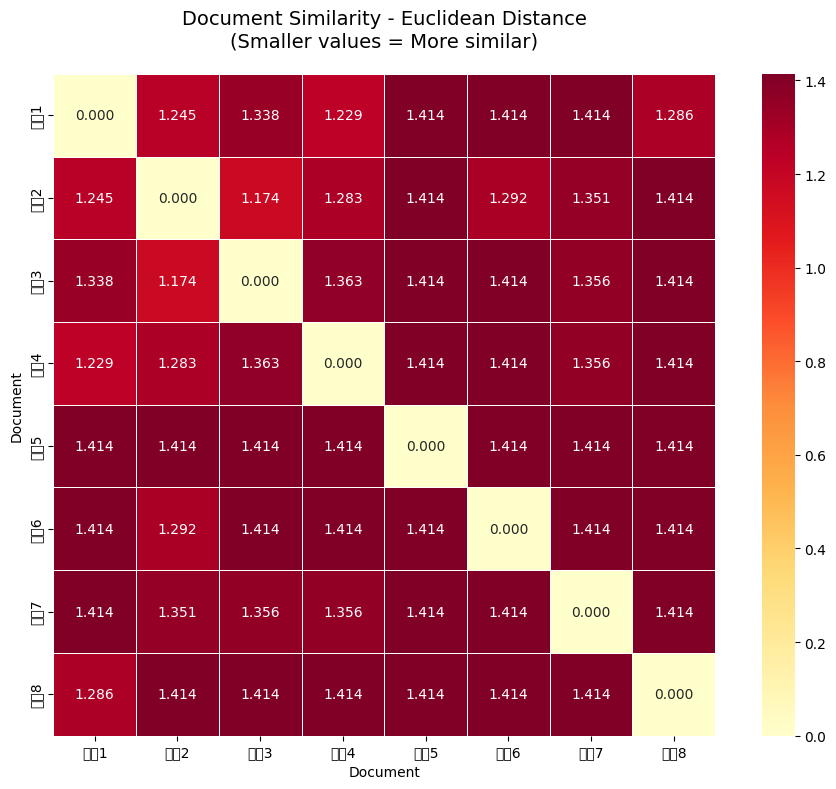

In [15]:
import jieba
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
# 设置显示选项
pd.set_option('display.max_columns', None)
# 显示DataFrame的所有列，不限制列数
pd.set_option('display.width', 1000)
# 设置控制台显示的宽度为1000字符
def simple_tfidf_analysis(documents):
    """
    简单的TF-IDF分析：分词、构建词表、计算TF-IDF
    """
    # 显示原始文档
    print("=== 原始文档 ===")
    for i, doc in enumerate(documents, 1):
        print("文档" + str(i) + ": " + doc)
    # 步骤1: 分词并用空格连接
    print("=== 步骤1: 分词处理 ===")
    processed_docs = []
    for i, doc in enumerate(documents, 1):
        # 使用jieba分词
        words = jieba.lcut(doc)
        # 用空格连接分词结果
        processed_doc = ' '.join(words)
        processed_docs.append(processed_doc)
        print("文档" + str(i) + ":")
        print("  原始: " + doc)
        print("  分词: " + str(words))
        print("  连接: '" + processed_doc + "'\n")
    print("=" * 60)
    # 步骤2: 使用TfidfVectorizer计算TF-IDF
    print("=== 步骤2: 计算TF-IDF ===")
    # 创建TF-IDF向量器，按空格分词
    # TfidfVectorizer是scikit-learn中用于将文本转换为TF-IDF特征向量的类
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None 
)
    #tokenizer指定分词器函数
    #lambda x: x.split()一个匿名函数，接收文本x，用空格进行分词
    # 拟合和转换数据
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
    print("TF-IDF计算完成！")
    print("矩阵形状: " + str(tfidf_matrix.shape) + " (文档数 × 词汇表大小)")
    # 步骤3: 获取词汇表
    print("=== 步骤3: 获取词汇表 ===")
    # 使用.get_feature_names_out()一键获取词汇表
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动构建的词汇表 (共" + str(len(feature_names)) + "个词):")
    # 每行显示5个词
    for i in range(0, len(feature_names), 5):
        line_words = feature_names[i:i+5]
        line_display = ""
        for j, word in enumerate(line_words):
            line_display += str(i+j+1) + "." + word + " " * (10 - len(word))
        print("  " + line_display)
    # 步骤4: 显示TF-IDF矩阵
    print("=== 步骤4: TF-IDF矩阵 ===")
    # 创建DataFrame显示结果
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=["文档" + str(i) for i in range(1, len(documents)+1)]
    )
    print("TF-IDF矩阵 (值越大表示词越重要):")
    print(tfidf_df.round(3))
    return tfidf_df, tfidf_vectorizer, processed_docs, tfidf_matrix
    #tfidf_df 类型：Pandas DataFrame 内容：TF-IDF矩阵的可视化表格形式 格式：行是文档，列是词语，单元格是TF-IDF值 用途：方便查看和展示结果（可视化结果）
    #tfidf_vectorizer 类型：TfidfVectorizer对象 内容：训练好的TF-IDF模型 包含：词汇表、参数设置、统计信息等 用途：可以用它处理新文档（处理工具）
    #processed_docs 类型：列表（list） 内容：分词后的文档集合 用途：保存预处理后的文本（输入数据）
    #tfidf_matrix 类型：稀疏矩阵（通常是scipy.sparse.csr_matrix） 内容：TF-IDF数值矩阵 格式：数学上的稀疏矩阵表示 用途：用于机器学习计算（数值计算）
documents = [
    "机器学习是人工智能的核心技术",
    "深度学习需要大量的训练数据",
    "监督学习使用标注数据进行训练",
    "Python是数据科学的首选语言",
    "Java在企业级开发中广泛应用",
    "数据分析需要统计学知识",
    "数据可视化帮助理解数据分布",
    "人工智能正在改变各行各业"
]
# 执行TF-IDF分析
tfidf_df, vectorizer, processed_docs, tfidf_matrix= simple_tfidf_analysis(documents)
# 显示统计信息
print("=== 统计信息 ===")
print("处理文档数量: " + str(len(documents)))
print("词汇表大小: " + str(len(vectorizer.get_feature_names_out())))
print("TF-IDF矩阵形状: " + str(tfidf_df.shape))
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import numpy as np
print("\n=== 方法1: 欧式距离相似度计算 ===")
# 计算所有文档对之间的欧式距离
#euclidean_distances() 函数会计算每两个文档向量之间的直线距离
euclidean_dist = euclidean_distances(tfidf_matrix)
# 创建欧式距离DataFrame
euclidean_df = pd.DataFrame(
    euclidean_dist,
    index=["文档" + str(i) for i in range(1, len(documents)+1)],
    columns=["文档" + str(i) for i in range(1, len(documents)+1)]
)
print("欧式距离矩阵 (值越小表示越相似):")
print(euclidean_df.round(3))
# 生成欧式距离热力图
print("=== Euclidean Distance Heatmap ===")
plt.figure(figsize=(10, 8))  # 设置图形大小

# 使用seaborn绘制热力图
heatmap = sns.heatmap(
    euclidean_df,           # 使用欧式距离DataFrame作为数据源
    annot=True,             # 在热力图中显示数值
    fmt=".3f",              # 数值格式，保留3位小数
    cmap="YlOrRd",          # 颜色映射：黄-橙-红色系，距离越大颜色越深
    linewidths=0.5,         # 设置单元格之间的线宽
    linecolor='white',      # 设置单元格之间的线颜色
    cbar=True,              # 显示颜色条
    square=True             # 使热力图为正方形
)

# 设置图表标题和标签
plt.title("Document Similarity - Euclidean Distance\n(Smaller values = More similar)", fontsize=14, pad=20)
plt.xlabel("Document")
plt.ylabel("Document")

# 优化显示
plt.tight_layout()

# 显示图形
plt.show()

=== 原始文档 ===
文档1: 机器学习是人工智能的核心技术
文档2: 深度学习需要大量的训练数据
文档3: 监督学习使用标注数据进行训练
文档4: Python是数据科学的首选语言
文档5: Java在企业级开发中广泛应用
文档6: 数据分析需要统计学知识
文档7: 数据可视化帮助理解数据分布
文档8: 人工智能正在改变各行各业
=== 步骤1: 分词处理 ===
文档1:
  原始: 机器学习是人工智能的核心技术
  分词: ['机器', '学习', '是', '人工智能', '的', '核心技术']
  连接: '机器 学习 是 人工智能 的 核心技术'

文档2:
  原始: 深度学习需要大量的训练数据
  分词: ['深度', '学习', '需要', '大量', '的', '训练', '数据']
  连接: '深度 学习 需要 大量 的 训练 数据'

文档3:
  原始: 监督学习使用标注数据进行训练
  分词: ['监督', '学习', '使用', '标注', '数据', '进行', '训练']
  连接: '监督 学习 使用 标注 数据 进行 训练'

文档4:
  原始: Python是数据科学的首选语言
  分词: ['Python', '是', '数据', '科学', '的', '首选', '语言']
  连接: 'Python 是 数据 科学 的 首选 语言'

文档5:
  原始: Java在企业级开发中广泛应用
  分词: ['Java', '在', '企业级', '开发', '中', '广泛应用']
  连接: 'Java 在 企业级 开发 中 广泛应用'

文档6:
  原始: 数据分析需要统计学知识
  分词: ['数据分析', '需要', '统计学', '知识']
  连接: '数据分析 需要 统计学 知识'

文档7:
  原始: 数据可视化帮助理解数据分布
  分词: ['数据', '可视化', '帮助', '理解', '数据分布']
  连接: '数据 可视化 帮助 理解 数据分布'

文档8:
  原始: 人工智能正在改变各行各业
  分词: ['人工智能', '正在', '改变', '各行各业']
  连接: '人工智能 正在 改变 各行各业'

=== 步骤2: 计算TF-IDF ===
TF-IDF计算完成！
矩

D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26723 (\N{CJK UNIFIED IDEOGRAPH-6863}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 26723 (\N{CJK UNIFIED IDEOGRAPH-6863}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Software\Program\anaconda3\envs\AI_Learning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.

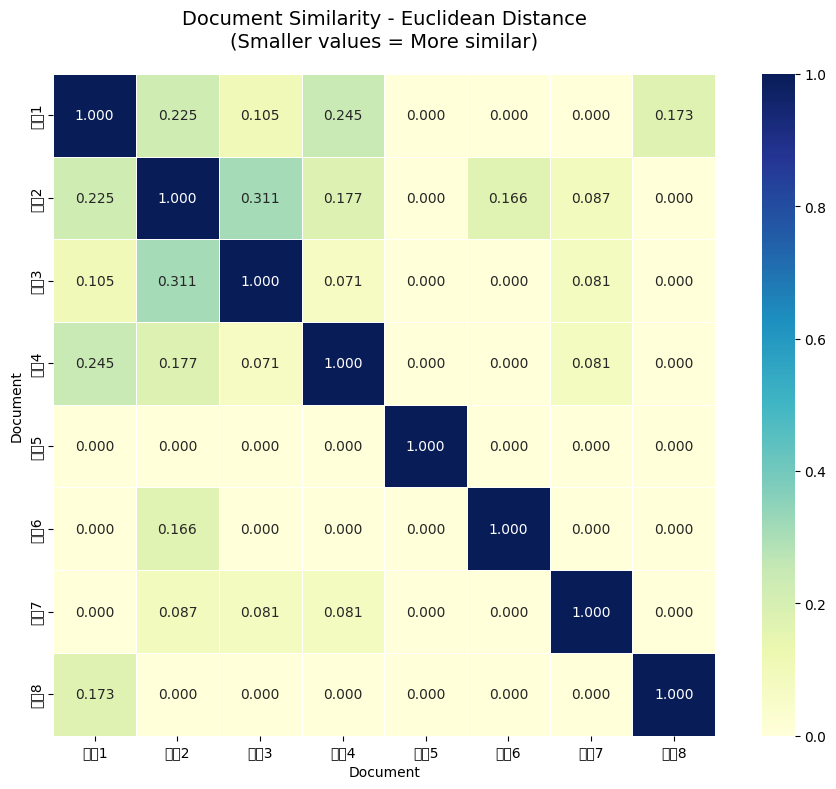

In [21]:
import jieba
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
# 设置显示选项
pd.set_option('display.max_columns', None)
# 显示DataFrame的所有列，不限制列数
pd.set_option('display.width', 1000)
# 设置控制台显示的宽度为1000字符
def simple_tfidf_analysis(documents):
    """
    简单的TF-IDF分析：分词、构建词表、计算TF-IDF
    """
    # 显示原始文档
    print("=== 原始文档 ===")
    for i, doc in enumerate(documents, 1):
        print("文档" + str(i) + ": " + doc)
    # 步骤1: 分词并用空格连接
    print("=== 步骤1: 分词处理 ===")
    processed_docs = []
    for i, doc in enumerate(documents, 1):
        # 使用jieba分词
        words = jieba.lcut(doc)
        # 用空格连接分词结果
        processed_doc = ' '.join(words)
        processed_docs.append(processed_doc)
        print("文档" + str(i) + ":")
        print("  原始: " + doc)
        print("  分词: " + str(words))
        print("  连接: '" + processed_doc + "'\n")
    print("=" * 60)
    # 步骤2: 使用TfidfVectorizer计算TF-IDF
    print("=== 步骤2: 计算TF-IDF ===")
    # 创建TF-IDF向量器，按空格分词
    # TfidfVectorizer是scikit-learn中用于将文本转换为TF-IDF特征向量的类
    tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None  
)
    #tokenizer指定分词器函数
    #lambda x: x.split()一个匿名函数，接收文本x，用空格进行分词
    # 拟合和转换数据
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
    print("TF-IDF计算完成！")
    print("矩阵形状: " + str(tfidf_matrix.shape) + " (文档数 × 词汇表大小)")
    # 步骤3: 获取词汇表
    print("=== 步骤3: 获取词汇表 ===")
    # 使用.get_feature_names_out()一键获取词汇表
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("自动构建的词汇表 (共" + str(len(feature_names)) + "个词):")
    # 每行显示5个词
    for i in range(0, len(feature_names), 5):
        line_words = feature_names[i:i+5]
        line_display = ""
        for j, word in enumerate(line_words):
            line_display += str(i+j+1) + "." + word + " " * (10 - len(word))
        print("  " + line_display)
    # 步骤4: 显示TF-IDF矩阵
    print("=== 步骤4: TF-IDF矩阵 ===")
    # 创建DataFrame显示结果
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=feature_names,
        index=["文档" + str(i) for i in range(1, len(documents)+1)]
    )
    print("TF-IDF矩阵 (值越大表示词越重要):")
    print(tfidf_df.round(3))
    return tfidf_df, tfidf_vectorizer, processed_docs, tfidf_matrix 
documents = [
    "机器学习是人工智能的核心技术",
    "深度学习需要大量的训练数据",
    "监督学习使用标注数据进行训练",
    "Python是数据科学的首选语言",
    "Java在企业级开发中广泛应用",
    "数据分析需要统计学知识",
    "数据可视化帮助理解数据分布",
    "人工智能正在改变各行各业"
]
# 执行TF-IDF分析
tfidf_df, vectorizer, processed_docs, tfidf_matrix = simple_tfidf_analysis(documents)
# 显示统计信息
print("=== 统计信息 ===")
print("处理文档数量: " + str(len(documents)))
print("词汇表大小: " + str(len(vectorizer.get_feature_names_out())))
print("TF-IDF矩阵形状: " + str(tfidf_df.shape))
# 计算余弦相似度
print("\n=== 方法2: 余弦相似度计算 ===")
# 计算所有文档对之间的余弦相似度
cosine_sim = cosine_similarity(tfidf_matrix)
# 创建余弦相似度DataFrame
cosine_df = pd.DataFrame(
    cosine_sim,
    index=["文档" + str(i) for i in range(1, len(documents)+1)],
    columns=["文档" + str(i) for i in range(1, len(documents)+1)]
)
print("余弦相似度矩阵 (值越大表示越相似):")
print(cosine_df.round(3))
# 生成余弦相似度热力图
print("=== Euclidean Distance Heatmap ===")
plt.figure(figsize=(10, 8))

# 使用seaborn绘制余弦相似度热力图
heatmap_cosine = sns.heatmap(
    cosine_df,              # 使用余弦相似度DataFrame作为数据源
    annot=True,             # 显示数值
    fmt=".3f",              # 数值格式，保留3位小数
    cmap="YlGnBu",          # 颜色映射：黄-绿-蓝色系，相似度越高颜色越深
    linewidths=0.5,         # 单元格之间的线宽
    linecolor='white',      # 单元格之间的线颜色
    cbar=True,              # 显示颜色条
    square=True,            # 使热力图为正方形
    vmin=0, vmax=1          # 设置颜色范围，余弦相似度在0-1之间
)

# 设置图表标题和标签
plt.title("Document Similarity - Euclidean Distance\n(Smaller values = More similar)", fontsize=14, pad=20)
plt.xlabel("Document")
plt.ylabel("Document")

# 优化显示
plt.tight_layout()
